Part_E

In [15]:
import pandas as pd
import numpy as np
from math import comb, exp, factorial

df = pd.read_csv("d2_graduates.csv")

df.head(10)

,grad_id,track,assessment_score,starting_salary_k,interviews,offers,days_to_first_offer
0,G-1001,Data Science,73.2,16.8,7,5,69
1,G-1002,Data Science,77.5,16.4,6,2,43
2,G-1003,Data Science,88.9,12.2,7,4,23
3,G-1004,Data Science,74.9,13.3,6,1,174
4,G-1005,Data Science,93.4,45.2,5,3,59
5,G-1006,Data Science,74.7,11.1,4,1,58
6,G-1007,Data Science,79.0,8.6,2,0,66
7,G-1008,Data Science,74.1,24.0,2,1,29
8,G-1009,Data Science,80.8,17.6,9,3,36
9,G-1010,Data Science,71.6,10.9,6,1,67


In [16]:
# Check the number of graduates
number_of_graduates = len(df)

# Check the possible outcomes
unique_offers = df["offers"].unique()

# Check the range of interviews
min_interviews = df["interviews"].min()
max_interviews = df["interviews"].max()

print("Number of graduates:", number_of_graduates)
print("Possible offer values:", unique_offers)
print("Minimum interviews:", min_interviews)
print("Maximum interviews:", max_interviews)

Number of graduates: 300
Possible offer values: [5 2 4 1 3 0 6 7]
Minimum interviews: 1
Maximum interviews: 14


In [17]:
# Calculate total interviews and total offers
total_interviews = df["interviews"].sum()
total_offers = df["offers"].sum()

# Calculate the overall probability of receiving an offer
p = total_offers / total_interviews

print("Total interviews:", total_interviews)
print("Total offers:", total_offers)
print("Overall offer probability (p):", p)

Total interviews: 1646
Total offers: 480
Overall offer probability (p): 0.2916160388821385


In [18]:
# Number of interviews
n = 6

# Probability of exactly 2 offers
k = 2

prob_2_offers = comb(n, k) * (p ** k) * ((1 - p) ** (n - k))

print("P(X = 2):", prob_2_offers)
print("Percentage:", prob_2_offers * 100)

P(X = 2): 0.32120992074773547
Percentage: 32.12099207477355


In [19]:
# Probability of getting zero offers out of 6 interviews
prob_0_offers = (1 - p) ** n

print("P(X = 0):", prob_0_offers)
print("Percentage:", prob_0_offers * 100)

P(X = 0): 0.12636078559378133
Percentage: 12.636078559378133


In [20]:
# Probability of at least one offer
prob_at_least_one = 1 - prob_0_offers

print("P(X >= 1):", prob_at_least_one)
print("Percentage:", prob_at_least_one * 100)

P(X >= 1): 0.8736392144062186
Percentage: 87.36392144062187


In [21]:
# Mean and variance of the binomial distribution
mean_binomial = n * p
variance_binomial = n * p * (1 - p)

print("Mean:", mean_binomial)
print("Variance:", variance_binomial)

Mean: 1.749696233292831
Variance: 1.2394567484929775


In [24]:
# Calculate probabilities for 0 to 6 offers
probabilities = []

for k in range(n + 1):
    probability = comb(n, k) * (p ** k) * ((1 - p) ** (n - k))
    probabilities.append(probability)

# Display the probabilities
for k, probability in enumerate(probabilities):
    print(f"P(X={k}) = {probability:.4f}")

P(X=0) = 0.1264
P(X=1) = 0.3121
P(X=2) = 0.3212
P(X=3) = 0.1763
P(X=4) = 0.0544
P(X=5) = 0.0090
P(X=6) = 0.0006


In [25]:
# Count graduates with zero offers
zero_offer_count = (df["offers"] == 0).sum()

# Calculate the observed proportion
observed_zero_proportion = zero_offer_count / len(df)

print("Number of graduates with zero offers:", zero_offer_count)
print("Observed proportion:", observed_zero_proportion)
print("Percentage:", observed_zero_proportion * 100)

Number of graduates with zero offers: 66
Observed proportion: 0.22
Percentage: 22.0


In [26]:
# Predicted probability of zero offers for each graduate
df["predicted_zero_probability"] = (1 - p) ** df["interviews"]

# Average predicted proportion of zero-offer graduates
predicted_zero_proportion = df["predicted_zero_probability"].mean()

print("Observed zero-offer proportion:", observed_zero_proportion)
print("Predicted zero-offer proportion:", predicted_zero_proportion)
print("Observed percentage:", observed_zero_proportion * 100)
print("Predicted percentage:", predicted_zero_proportion * 100)

Observed zero-offer proportion: 0.22
Predicted zero-offer proportion: 0.19364018691554302
Observed percentage: 22.0
Predicted percentage: 19.364018691554303


Part_F

In [ ]:
helpdesk = pd.read_csv(r"F:\ITI\statistcs\d2_helpdesk.csv")

helpdesk.head(10)

,date,lab,tickets_logged
0,2025-09-01,Lab C,3
1,2025-09-02,Lab C,3
2,2025-09-03,Lab A,6
3,2025-09-04,Lab C,5
4,2025-09-05,Lab A,7
5,2025-09-06,Lab C,3
6,2025-09-07,Lab C,2
7,2025-09-08,Lab C,2
8,2025-09-09,Lab C,4
9,2025-09-10,Lab B,2


In [29]:
# Calculate the mean number of tickets
mean_tickets = helpdesk["tickets_logged"].mean()

# Calculate the sample variance
sample_variance = helpdesk["tickets_logged"].var()

print("Mean tickets per day:", mean_tickets)
print("Sample variance:", sample_variance)

Mean tickets per day: 3.7055555555555557
Sample variance: 3.6055555555555494


In [30]:
# Check the minimum and maximum number of tickets
min_tickets = helpdesk["tickets_logged"].min()
max_tickets = helpdesk["tickets_logged"].max()

print("Minimum tickets in a day:", min_tickets)
print("Maximum tickets in a day:", max_tickets)

Minimum tickets in a day: 0
Maximum tickets in a day: 9


In [31]:
# Set lambda as the mean rounded to one decimal place
lambda_poisson = round(mean_tickets, 1)

print("Lambda:", lambda_poisson)

Lambda: 3.7


In [32]:
# Probability of exactly 2 tickets
k = 2

prob_2_tickets = (exp(-lambda_poisson) * lambda_poisson**k) / factorial(k)

print("P(X = 2):", prob_2_tickets)
print("Percentage:", prob_2_tickets * 100)

P(X = 2): 0.16923253868947313
Percentage: 16.923253868947313


In [33]:
# Probability of zero tickets
k = 0

prob_0_tickets = (exp(-lambda_poisson) * lambda_poisson**k) / factorial(k)

print("P(X = 0):", prob_0_tickets)
print("Percentage:", prob_0_tickets * 100)

P(X = 0): 0.024723526470339388
Percentage: 2.4723526470339388


In [34]:
# Probability of exactly 1 ticket
k = 1

prob_1_ticket = (exp(-lambda_poisson) * lambda_poisson**k) / factorial(k)

# Probability of at least 2 tickets
prob_at_least_2 = 1 - prob_0_tickets - prob_1_ticket

print("P(X >= 2):", prob_at_least_2)
print("Percentage:", prob_at_least_2 * 100)

P(X >= 2): 0.8837994255894048
Percentage: 88.37994255894048


In [35]:
# Calculate the probability of 0 through 6 tickets
prob_0_to_6 = 0

for k in range(7):
    probability = (exp(-lambda_poisson) * lambda_poisson**k) / factorial(k)
    prob_0_to_6 += probability

# Probability of more than 6 tickets
prob_more_than_6 = 1 - prob_0_to_6

print("P(X > 6):", prob_more_than_6)
print("Percentage:", prob_more_than_6 * 100)

P(X > 6): 0.08180919827326472
Percentage: 8.180919827326472


In [36]:
# Expected number of days with more than 6 tickets
expected_high_ticket_days = 180 * prob_more_than_6

print("Expected days with more than 6 tickets:", expected_high_ticket_days)

Expected days with more than 6 tickets: 14.725655689187649


In [38]:
# Observed frequency of each ticket count
observed_frequency = helpdesk["tickets_logged"].value_counts().sort_index()

print(observed_frequency)

tickets_logged
0     5
1    12
2    40
3    24
4    46
5    24
6    13
7    10
8     3
9     3
Name: count, dtype: int64


In [39]:
# Create expected frequencies using the Poisson model
ticket_values = range(0, 10)

expected_frequency = []

for k in ticket_values:
    probability = (exp(-lambda_poisson) * lambda_poisson**k) / factorial(k)
    expected_days = 180 * probability
    expected_frequency.append(expected_days)

# Create a comparison table
comparison = pd.DataFrame({
    "Tickets": ticket_values,
    "Observed Days": [
        observed_frequency.get(k, 0) for k in ticket_values
    ],
    "Expected Days": expected_frequency
})

comparison

,Tickets,Observed Days,Expected Days
0,0,5,4.450235
1,1,12,16.465869
2,2,40,30.461857
3,3,24,37.569624
4,4,46,34.751902
5,5,24,25.716407
6,6,13,15.858451
7,7,10,8.382324
8,8,3,3.876825
9,9,3,1.593806


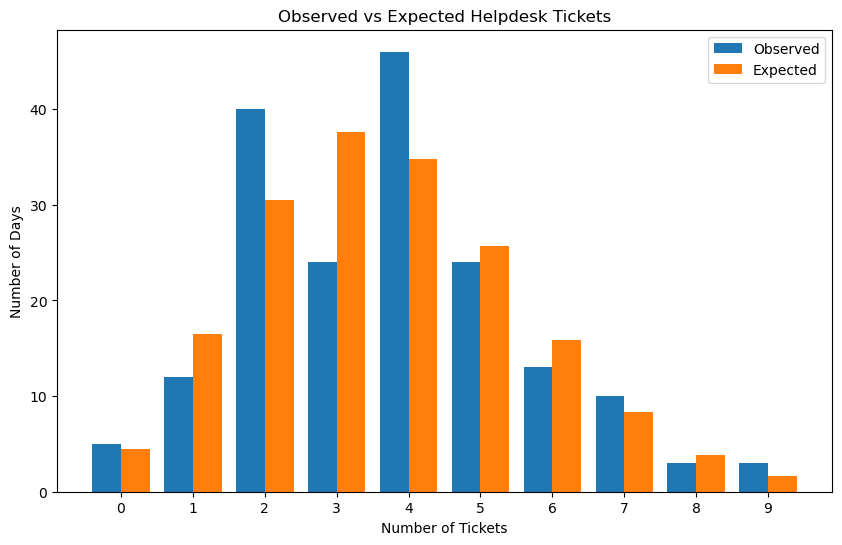

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    comparison["Tickets"] - 0.2,
    comparison["Observed Days"],
    width=0.4,
    label="Observed"
)

plt.bar(
    comparison["Tickets"] + 0.2,
    comparison["Expected Days"],
    width=0.4,
    label="Expected"
)

plt.xlabel("Number of Tickets")
plt.ylabel("Number of Days")
plt.title("Observed vs Expected Helpdesk Tickets")
plt.xticks(comparison["Tickets"])
plt.legend()
plt.show()